lower_left : [22.875001151143998, 75.72499809971262]
upper_right: [31.45833369739237, 82.06666469081911]


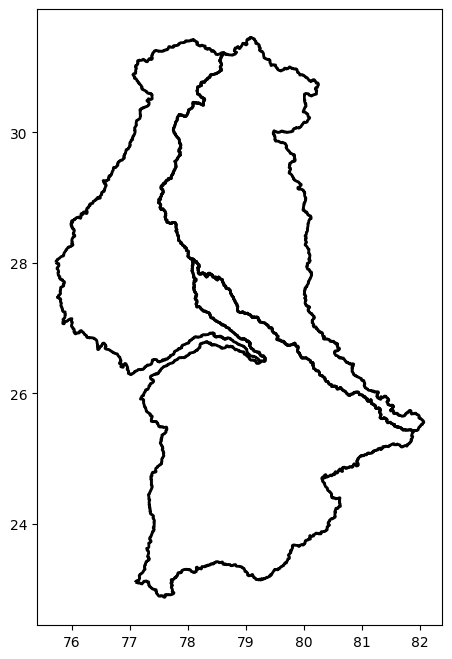

In [1]:
# Getting basin outline using Hydroshed basin boundary from running GEE script

import geopandas as gpd
import pandas as pd
import json
from shapely.geometry import shape
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

# Paths
csv_path = 'Chamoli_3_basins.csv'
output_plot = 'basin_outline.png'

# Load basin outline
df = pd.read_csv(csv_path)
df['geometry'] = df['.geo'].apply(lambda x: shape(json.loads(x)))
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

# Plot basin outline only
fig, ax = plt.subplots(figsize=(8, 8))

gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=2)

west, south, east, north = gdf.total_bounds

# lsdstreamburn.get_dem wants [lat, lon]
lower_left  = [south, west]   # [min_lat, min_lon]
upper_right = [north, east]   # [max_lat, max_lon]

print("lower_left :", lower_left)
print("upper_right:", upper_right)

In [ ]:
# When the overall area is too big and return 400 error in opentopography API,
# you can pick one basin by its HYBAS_ID, download each basin DEM separately, and then mosaic them together.

# after gdf is created
gdf[["HYBAS_ID","PFAF_ID","system:index"]].head()  # pick an id you want

# sub = gdf[gdf["HYBAS_ID"] == 4050911450]  # <-- choose one basin
sub = gdf.iloc[[2]]  # pick by row number

west, south, east, north = sub.total_bounds

lower_left  = [south, west]
upper_right = [north, east]
print("lower_left :", lower_left)
print("upper_right:", upper_right)

lower_left : [25.420831186619758, 77.49166722010087]
upper_right: [31.45833369739237, 82.06666469081911]


In [11]:
import lsdstreamburn.lsdstreamburn as sb
my_dem = sb.get_dem(OT_api_key_fname = "../my_OT_api_key.txt", 
                    source = "AW3D30", 
                    lower_left = lower_left, 
                    upper_right = upper_right,
                    prefix = "Chamoli_pop_area")

print(my_dem)

I am taking your coordinates from the lower left list
I am taking your coordinates from the upper right list
I am reading you OT API key from the file ../my_OT_api_key.txt
The grid spacing for your DEM will be:30
I am going to download a file from opentopography (I've removed the API key):
https://portal.opentopography.org/API/globaldem?demtype=AW3D30&south=25.420831186619758&north=31.45833369739237&west=77.49166722010087&east=82.06666469081911&outputFormat=GTiff
This might take a little while, depending on the size of the file. 
The filename will be:
./Chamoli_pop_area_AW3D30.tif
The path and file without path are:
./  Chamoli_pop_area_AW3D30.tif
Finished downloading
./Chamoli_pop_area_AW3D30.tif


In [14]:
# TODO: mosaic multiple DEMs if needed
import rasterio
from rasterio.merge import merge

paths = [
    "Chamoli_pop_area_AW3D30_basin1.tif",
    "Chamoli_pop_area_AW3D30_basin2.tif",
    "Chamoli_pop_area_AW3D30_basin3.tif",
]

srcs = [rasterio.open(p) for p in paths]
mosaic, out_transform = merge(srcs)

out_meta = srcs[0].meta.copy()
out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform,
})

out_path = "Chamoli_pop_area_AW3D30_mosaic.tif"
with rasterio.open(out_path, "w", **out_meta) as dest:
    dest.write(mosaic)

for s in srcs:
    s.close()

In [15]:
my_dem = out_path

In [ ]:
with rasterio.open(my_dem) as src:
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot DEM
    show(src, ax=ax, cmap='terrain')

    # Reproject basin outlines to DEM CRS if needed
    if gdf.crs != src.crs:
        gdf_plot = gdf.to_crs(src.crs)
    else:
        gdf_plot = gdf

    # Plot basin outline on top
    gdf_plot.boundary.plot(ax=ax, edgecolor='black', linewidth=2)

    ax.set_title("Chamoli basin outline over AW3D30 DEM")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.savefig(output_plot, dpi=300)
    plt.close(fig)

print("Saved combined plot to:", output_plot)

Saved combined plot to: basin_outline.png
